# 01 · Vectors and matrices: learn by coding

**Prerequisites:** Python lists, loops, functions, and indexing. No prior linear algebra required.
**Time:** about 60–90 minutes, including exercises.

Work from top to bottom. For each example: **predict → run → explain → change one input**.
Use the project's `.venv` kernel. Only NumPy and Matplotlib are needed; no downloads or datasets.

## What you will be able to do

- Translate scalars, vectors, and matrices into NumPy arrays and explain their shapes.
- Implement vector addition and a dot product with loops, then check against NumPy.
- Interpret length, direction, linear combinations, and matrix–vector multiplication.
- Diagnose elementwise-operation and broadcasting mistakes.
- Calculate a batch of predictions from a feature matrix and explain each dimension.

This notebook introduces matrix–vector products. General matrix multiplication, inverses, and
linear systems belong in the next notebook; eigenvalues and SVD come later.

## 1. Numbers become arrays

A **scalar** is one number. A **vector** is an ordered list of numbers; its entries might describe
one sample's features. A **matrix** is a rectangular table of numbers. We will use rows for samples
and columns for features. This is a convention, so always state it.

Mathematically, a vector in $\mathbb{R}^n$ has $n$ real coordinates. In NumPy, `ndim` counts array
axes, while `shape` gives the length of each axis. A three-coordinate vector has `ndim == 1`,
not 3. `dtype` describes how its numbers are stored.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=True)

scalar = np.array(2.0)
vector = np.array([2.0, 3.0, 4.0])
matrix = np.array([[2.0, 3.0, 4.0], [5.0, 6.0, 7.0]])
for name, value in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(f"{name}: shape={value.shape}, ndim={value.ndim}, dtype={value.dtype}")
assert matrix.shape == (2, 3)

scalar: shape=(), ndim=0, dtype=float64
vector: shape=(3,), ndim=1, dtype=float64
matrix: shape=(2, 3), ndim=2, dtype=float64


### Checkpoint: rows, columns, and a common trap

Predict the four shapes below. A 1D array has no separate row or column axis, so `v.T` does
not turn it into a column. Use `reshape` or `None` to add an axis explicitly.

In [2]:
v = np.array([1.0, 2.0, 3.0])
row = v.reshape(1, -1)  # -1 asks NumPy to infer this dimension
column = v[:, None]
print("v:", v.shape, "v.T:", v.T.shape)
print("row:", row.shape, "column:", column.shape)
assert row.shape == (1, 3)
assert column.shape == (3, 1)

v: (3,) v.T: (3,)
row: (1, 3) column: (3, 1)


## 2. Add and scale vectors

For vectors of equal length, addition works coordinate by coordinate:
$[u_1,u_2]+[v_1,v_2]=[u_1+v_1,u_2+v_2]$.
Scaling multiplies every coordinate: $a[u_1,u_2]=[au_1,au_2]$.
Geometrically, addition combines displacements; positive scaling changes length,
and negative scaling also reverses direction.

First implement addition with ordinary Python. Check lengths explicitly: `zip` alone would
silently stop at the shorter input. These teaching functions accept 1D real numeric sequences.

In [4]:
def add_vectors(left, right):
    if len(left) != len(right):
        raise ValueError("Vectors must have the same length")
    return [x + y for x, y in zip(left, right)]


u = np.array([3.0, 1.0])
v = np.array([1.0, 2.0])
manual_sum = add_vectors(u, v)
print("loop:", manual_sum, "NumPy:", u + v)
print("2u:", 2 * u, "u - v:", u - v)
np.testing.assert_allclose(manual_sum, u + v)

# Python lists concatenate; NumPy arrays add coordinate by coordinate.
print("lists:", [3, 1] + [1, 2])
print("arrays:", np.array([3, 1]) + np.array([1, 2]))

loop: [np.float64(4.0), np.float64(3.0)] NumPy: [4. 3.]
2u: [6. 2.] u - v: [ 2. -1.]
lists: [3, 1, 1, 2]
arrays: [4 3]


### Experiment: draw the addition

Predict where `u + v` ends. Change `u` or `v` in the previous cell and rerun both cells.
The dotted arrow moves `v` to the tip of `u`; its endpoint matches the sum.
Equal axis scales keep the geometry faithful.

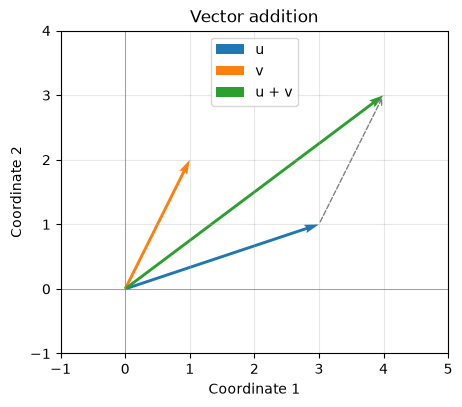

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
for arrow, label, color in [
    (u, "u", "tab:blue"),
    (v, "v", "tab:orange"),
    (u + v, "u + v", "tab:green"),
]:
    ax.quiver(0, 0, *arrow, angles="xy", scale_units="xy", scale=1, color=color, label=label)
ax.annotate(
    "", xy=u + v, xytext=u, arrowprops={"arrowstyle": "->", "linestyle": "--", "color": "gray"}
)
points = np.vstack([np.zeros(2), u, v, u + v])
ax.set_xlim(points[:, 0].min() - 1, points[:, 0].max() + 1)
ax.set_ylim(points[:, 1].min() - 1, points[:, 1].max() + 1)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set(xlabel="Coordinate 1", ylabel="Coordinate 2", title="Vector addition")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 3. Linear combinations and span

A **linear combination** is a weighted sum of vectors: $a u + b v$.
Their **span** is the set of all results as the real weights vary.
The standard basis vectors $e_1=[1,0]$ and $e_2=[0,1]$ can build any vector in the plane.
They are independent: neither can be made by scaling the other.
By contrast, $[1,2]$ and $[2,4]$ span only a line because the second is twice the first.

In [6]:
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])
target = 3 * e1 - 2 * e2
print("Standard-basis combination:", target)
np.testing.assert_allclose(target, [3, -2])

p = np.array([1.0, 2.0])
q = 2 * p
for a, b in [(1, 0), (0, 1), (3, -1), (-2, 4)]:
    combination = a * p + b * q
    print(f"{a}p + {b}q = {combination}")
    assert np.isclose(combination[1], 2 * combination[0])

Standard-basis combination: [ 3. -2.]
1p + 0q = [1. 2.]
0p + 1q = [2. 4.]
3p + -1q = [1. 2.]
-2p + 4q = [ 6. 12.]


**Try it:** Can any weights on `p` and `q` produce `[1, 0]`? Explain using the relationship
between the two coordinates, rather than trying many random weights.

## 4. Dot product: multiply, then add

For real vectors, $u \cdot v = \sum_i u_i v_i$. The result is a scalar.
In a weighted score, each feature is multiplied by its weight and the contributions are added.
For two 1D arrays, `u @ v` and `np.dot(u, v)` compute this sum; `u * v` keeps each contribution.

Predict: `[2, 3, 1]` dotted with `[4, -1, 2]` gives $8-3+2=7$.

In [7]:
def dot_product(left, right):
    if len(left) != len(right):
        raise ValueError("Vectors must have the same length")
    total = 0.0
    for x, y in zip(left, right):
        total += x * y
    return total


features = np.array([2.0, 3.0, 1.0])
weights = np.array([4.0, -1.0, 2.0])
print("Contributions:", features * weights)
print("Total:", dot_product(features, weights))
np.testing.assert_allclose(dot_product(features, weights), features @ weights)
assert np.isclose(features @ weights, 7)

# Mismatched inputs should fail clearly, rather than lose coordinates.
try:
    dot_product([1, 2], [3])
except ValueError as error:
    print("Expected error:", error)
else:
    raise AssertionError("A length mismatch must be rejected")

Contributions: [ 8. -3.  2.]
Total: 7.0
Expected error: Vectors must have the same length


## 5. Length and direction

The Euclidean norm is $\|v\|_2=\sqrt{v\cdot v}$. For `[3, 4]` it is 5.
Dividing a nonzero vector by its norm produces a **unit vector** pointing in the same direction.
The zero vector has no direction, so normalization must handle it explicitly.

For nonzero real vectors, cosine similarity is $(u\cdot v)/(\|u\|\|v\|)$.
It is 1 for the same direction, 0 for perpendicular directions, and −1 for opposite directions.
Here we use real numbers throughout; complex inner products require conjugation.

In [ ]:
def unit_vector(values):
    values = np.asarray(values, dtype=float)
    length = np.linalg.norm(values)
    if length == 0:
        raise ValueError("The zero vector cannot be normalized")
    return values / length


v = np.array([3.0, 4.0])
manual_length = np.sqrt(dot_product(v, v))
print("Length:", manual_length, "Unit vector:", unit_vector(v))
np.testing.assert_allclose(manual_length, np.linalg.norm(v))
np.testing.assert_allclose(np.linalg.norm(unit_vector(v)), 1)
for other in [v, -v, np.array([-4.0, 3.0])]:
    print("Cosine similarity:", unit_vector(v) @ unit_vector(other))
try:
    unit_vector([0, 0])
except ValueError as error:
    print("Expected error:", error)
else:
    raise AssertionError("Normalization must reject the zero vector")

## 6. Matrices organize data

Let $X$ have shape $(m,n)$: $m$ samples and $n$ features. NumPy indexes from zero.
`X[i, j]` selects one number; `X[i]` selects a row; `X[:, j]` selects a column.
Selecting one column this way returns a 1D array. A slice such as `X[:, j:j+1]` keeps two axes.

Our toy table has three students and two features: study hours and practice sessions.
The numbers are invented for learning and do not establish a real relationship.

In [ ]:
X = np.array([[2.0, 1.0], [4.0, 3.0], [1.0, 2.0]])
print("Data shape:", X.shape)
print("Second student:", X[1])
print("Study hours:", X[:, 0])
print("One column as a matrix:", X[:, 0:1], X[:, 0:1].shape)
print("Transpose shape:", X.T.shape)
assert X[1, 0] == 4
assert X[:, 0].shape == (3,)
assert X[:, 0:1].shape == (3, 1)

### Axis reductions and broadcasting

`X.mean(axis=0)` averages over rows, leaving one mean per feature. `axis=1` averages over
columns, leaving one value per sample. A row average is meaningful only when feature units permit it.

Subtracting a shape `(2,)` mean vector from `(3, 2)` data applies the same means to every row.
This is **broadcasting**: NumPy compares shapes from the right; dimensions must match or one
must be 1. Always inspect shapes—valid broadcasting can still implement the wrong calculation.

In [ ]:
feature_means = X.mean(axis=0)
centered = X - feature_means
print("Feature means:", feature_means)
print("Centered data:\n", centered)
np.testing.assert_allclose(centered.mean(axis=0), np.zeros(2), atol=1e-12)

# A column minus a 1D vector creates all pairwise differences, not three residuals!
observed = np.array([10.0, 20.0, 30.0])
predicted_column = np.array([[9.0], [18.0], [27.0]])
print("Unexpected shape:", (observed - predicted_column).shape)
residuals = observed - predicted_column[:, 0]
print("Intended residuals:", residuals)
assert residuals.shape == (3,)

## 7. Matrix–vector multiplication, two ways

If $X$ has shape $(m,n)$ and $w$ has shape $(n,)$, then $Xw$ has shape $(m,)$.
Each output is one row's dot product with $w$. Equivalently, it is a linear combination
of the **columns** of $X$, using the entries of $w$ as weights.

For our data, choose weights `[5, 2]`. Predict the output by hand before running:
the first row gives $2(5)+1(2)=12$.

In [ ]:
w = np.array([5.0, 2.0])
by_rows = np.array([dot_product(row, w) for row in X])
by_columns = w[0] * X[:, 0] + w[1] * X[:, 1]
by_numpy = X @ w
print("Row dot products:", by_rows)
print("Weighted columns:", by_columns)
print("NumPy:", by_numpy)
np.testing.assert_allclose(by_rows, [12, 26, 9])
np.testing.assert_allclose(by_rows, by_numpy)
np.testing.assert_allclose(by_columns, by_numpy)
print("X * w retains contributions:\n", X * w)
assert (X * w).shape == (3, 2)
assert (X @ w).shape == (3,)

### A matrix can also transform a vector

Multiplying by the identity leaves coordinates unchanged. A diagonal matrix scales individual
coordinates. Its columns show where the standard basis vectors go.
Predict how `diag([2, 0.5])` changes `[3, 4]`.

In [ ]:
identity = np.eye(2)
stretch = np.diag([2.0, 0.5])
point = np.array([3.0, 4.0])
print("Transformed point:", stretch @ point)
print("Images of e1 and e2:", stretch @ e1, stretch @ e2)
np.testing.assert_allclose(identity @ point, point)
np.testing.assert_allclose(stretch @ point, [6, 2])

## 8. Mini project: a batch of predictions

Use $\hat y = Xw + b$, where each row is one student, `w` contains two feature weights, and
`b` is a scalar baseline. These weights are chosen by hand, **not fitted**. This is a calculation
exercise, not a validated prediction model.

1. Predict all three scores with a loop.
2. Compare with a single NumPy expression.
3. Calculate residuals as `observed - predicted` and mean squared error (MSE).
4. Increase the study-hours weight by 1. Predict how much each score changes.

MSE is the mean of squared residuals; smaller means closer on these examples.

In [ ]:
baseline = 40.0
observed_scores = np.array([53.0, 65.0, 50.0])
loop_predictions = np.array([dot_product(row, w) + baseline for row in X])
predictions = X @ w + baseline
assert predictions.shape == observed_scores.shape  # guard against broadcasting
np.testing.assert_allclose(loop_predictions, predictions)
residuals = observed_scores - predictions
mse = np.mean(residuals**2)
print("Predictions:", predictions)
print("Residuals:", residuals, "MSE:", mse)
np.testing.assert_allclose(predictions, [52, 66, 49])
assert np.isclose(mse, 1)

changed_w = w + np.array([1.0, 0.0])
prediction_change = (X @ changed_w + baseline) - predictions
print("Change after increasing first weight:", prediction_change)
np.testing.assert_allclose(prediction_change, X[:, 0])

## 9. Your turn — attempt before opening the solutions

Use the scratch cell below. Keep your variables separate from the worked examples.

1. For `a = [2, -1, 2]` and `b = [1, 3, 0]`, calculate `2a - b`, the dot product,
   the length of `a`, and its unit vector. Check your loop dot product against NumPy.
2. For `A = [[1, 2], [3, 4], [5, 6]]` and `z = [2, -1]`, predict the shapes of
   `A * z` and `A @ z`, then calculate both. Rebuild `A @ z` from its columns.
3. Center the columns of `A`. Verify their means are approximately zero.
4. Explain why `[1, 2]` and `[2, 4]` cannot combine to make `[1, 0]`.
5. In the mini project, increase the baseline by 3. How does every prediction change?

Use `np.testing.assert_allclose` for floating-point results; rounding can make exact equality
inappropriate. Use exact equality for integer shapes.

In [ ]:
# Write your attempt here, then compare with the solutions below.
# Suggested starting point:
# a = np.array([2.0, -1.0, 2.0])
# b = np.array([1.0, 3.0, 0.0])

<details>
<summary>Solutions — open after your attempt</summary>

```python
a = np.array([2.0, -1.0, 2.0])
b = np.array([1.0, 3.0, 0.0])
np.testing.assert_allclose(2 * a - b, [3, -5, 4])
assert np.isclose(dot_product(a, b), -1)
np.testing.assert_allclose(dot_product(a, b), a @ b)
assert np.isclose(np.linalg.norm(a), 3)
np.testing.assert_allclose(unit_vector(a), [2/3, -1/3, 2/3])

A = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
z = np.array([2.0, -1.0])
assert (A * z).shape == (3, 2)
assert (A @ z).shape == (3,)
np.testing.assert_allclose(A * z, [[2, -2], [6, -4], [10, -6]])
np.testing.assert_allclose(A @ z, [0, 2, 4])
np.testing.assert_allclose(A @ z, 2 * A[:, 0] - A[:, 1])
A_centered = A - A.mean(axis=0)
np.testing.assert_allclose(A_centered.mean(axis=0), [0, 0], atol=1e-12)
np.testing.assert_allclose((X @ w + baseline + 3) - predictions, [3, 3, 3])
```

Every combination of `[1, 2]` and `[2, 4]` has its second coordinate equal to twice
its first. `[1, 0]` does not satisfy that relationship, so it is outside their span.

</details>

## 10. Takeaway and next step

Complete these in your own words:

- A vector's number of coordinates differs from NumPy's `ndim` because …
- `*` and `@` produced different results because …
- I can explain `X @ w` using rows as … and columns as …
- One broadcasting mistake I can now recognize is …
- Changing a weight affected …; changing the baseline affected …

**Completion check:** Restart the kernel and run all cells. Explain the mini project's shapes
without looking at the output, then complete the practice exercises independently.

Continue with [02 Matrix operations](02_matrix_operations.ipynb).

## Resources and reading guide

The explanations and exercises above are original coding examples.

- [Sheldon Axler, *Linear Algebra Done Right*, fourth edition](https://linear.axler.net/LADR4e.pdf).
  For further theory, explore vectors, span, and linear maps. The author's
  [fourth-edition video index](https://linear.axler.net/LADRvideos4e.html) lists
  Section 3A on linear maps and Section 3C on the matrix of a linear map.
  This notebook is an introductory numerical companion, not a chapter-by-chapter adaptation.
- [UNC MATH347DS textbook](http://mitran-lab.amath.unc.edu/courses/MATH347DS/textbook.pdf).
  User-supplied additional reading. The PDF could not be retrieved during preparation,
  so no specific sections or exercises are attributed to it.
- [How I Learned Linear Algebra, Probability, and Statistics for Data Science](https://towardsdatascience.com/how-i-learned-linear-algebra-probability-and-statistics-for-data-science-b9d1c34dfa56/).
  User-supplied learning-path reading. Automated access was blocked during preparation;
  the article is included for optional reading, not used as a verified technical source.